In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Preprocessing

In [86]:
# Preprocessig the data, loading in the data and overviewing it.
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [87]:
# fixing total charges to be numberic, and not read as a string
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.info()

# Checking for missing values and handling nulls by mean
df.isnull().sum()
df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)
df.isnull().sum()

# Encode target variable and categorical features
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.head()

# encode categorical variables using one-hot encoding, prevents multicollinearity by dropping the first category
df = pd.get_dummies(df, drop_first=True)
df.head()


# feature scaling for standardization of numeric features, as it is important for logistic regression.
scaler = StandardScaler()

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


/var/folders/00/kvvkjypx4lzc_971v9jszh2m0000gn/T/ipykernel_49331/3159616045.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-1.277445,-1.160323,-0.994971,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,0.066327,-0.259629,-0.173876,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,-1.236724,-0.362660,-0.960399,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,0.514251,-0.746535,-0.195400,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,-1.236724,0.197365,-0.941193,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


# Model 1: Logistic regression:

In [88]:
# 1. Separate features and target (customerID columns are already one-hot encoded)
X = df.drop('Churn', axis=1)
y = df['Churn']

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Scale features (helps logistic regression perform better)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train model (added regularization control)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# 5. Predictions
y_pred_log = log_model.predict(X_test_scaled)

# 6. Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))



Logistic Regression Accuracy: 0.7863733144073811

Confusion Matrix:
 [[990  46]
 [255 118]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.96      0.87      1036
           1       0.72      0.32      0.44       373

    accuracy                           0.79      1409
   macro avg       0.76      0.64      0.65      1409
weighted avg       0.78      0.79      0.75      1409



Model 2: Decision Tree model

In [89]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# 1. Features / target (customerID is already one-hot encoded, no need to drop)
X = df.drop('Churn', axis=1)
y = df['Churn']

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ❗ NOTE: No scaling needed for Decision Trees

# 4. Train model (added better regularization)
tree_model = DecisionTreeClassifier(
    max_depth=5,          # controls complexity
    min_samples_split=10, # prevents overfitting
    min_samples_leaf=5,   # smoother predictions
    random_state=42
)

tree_model.fit(X_train, y_train)

# 5. Predictions
y_pred_tree = tree_model.predict(X_test)

# 6. Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.8076650106458482

Confusion Matrix:
 [[966  70]
 [201 172]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.93      0.88      1036
           1       0.71      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409



Model 3: Random Forest model

In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import pandas as pd

# Use the already encoded target (no need to map again)
y = df['Churn']

# Ensure all features are numeric by dropping non-numeric helper columns like Churn_Label
X = df.select_dtypes(include='number').drop('Churn', axis=1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions using probabilities
y_probs = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_probs > 0.4).astype(int)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.716820440028389

Confusion Matrix:
 [[705 331]
 [ 68 305]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.68      0.78      1036
           1       0.48      0.82      0.60       373

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.69      1409
weighted avg       0.80      0.72      0.73      1409



Model Comparison:

In [91]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.786373
1        Decision Tree  0.807665
2        Random Forest  0.735273


Visualizations:

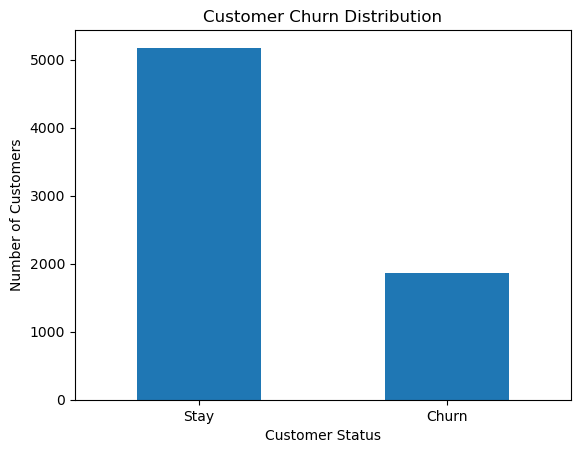

In [92]:
# Churn Distribution: How many costumers churned vs how many stayed:
import matplotlib.pyplot as plt

df['Churn_Label'] = df['Churn'].map({0: 'Stay', 1: 'Churn'})

df['Churn_Label'].value_counts().plot(kind='bar')

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

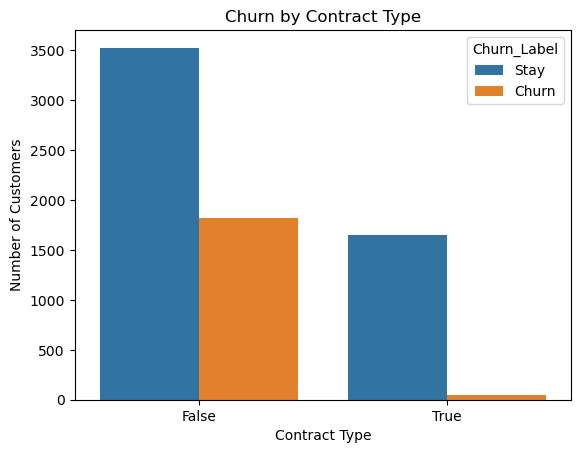

In [93]:
# Contract type vs churn: how many costumers with different contract types churned vs stayed:

import seaborn as sns

plt.figure()
sns.countplot(x='Contract_Two year', hue='Churn_Label', data=df)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

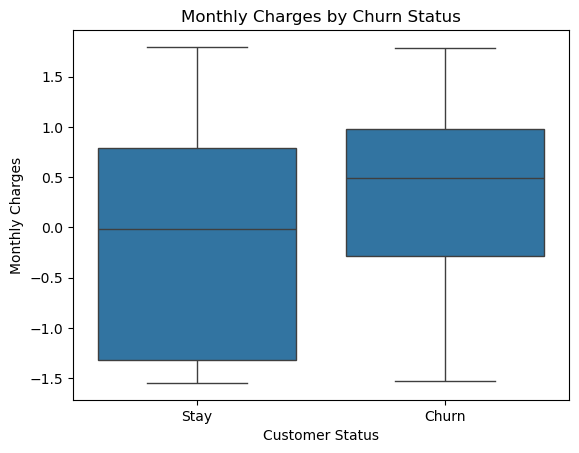

In [94]:
# Monthly Charges vs Churn: how many costumers with different monthly charges churned vs stayed:

plt.figure()
sns.boxplot(x='Churn_Label', y='MonthlyCharges', data=df)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges")

plt.show()

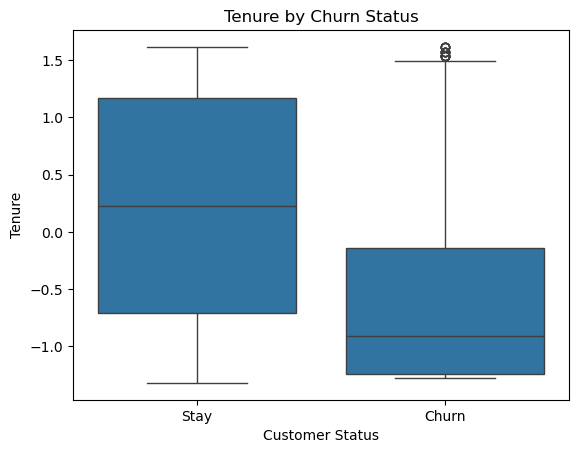

In [95]:
# Tenture vs Churn: how many costumers with different tenure churned vs stayed:

plt.figure()
sns.boxplot(x='Churn_Label', y='tenure', data=df)

plt.title("Tenure by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Tenure")

plt.show()

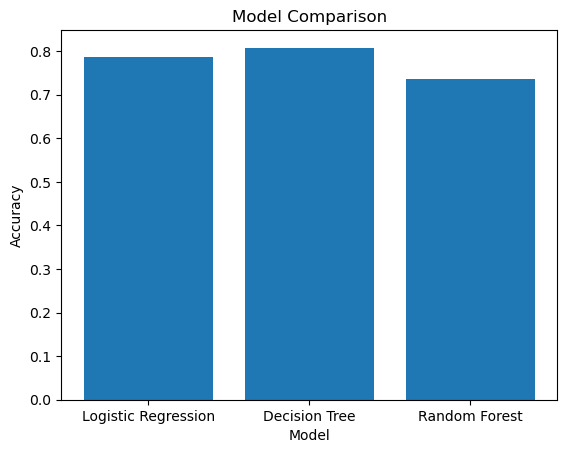

In [96]:
# Model Comparison:
plt.figure()
plt.bar(results['Model'], results['Accuracy'])

plt.title("Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=0)

plt.show()

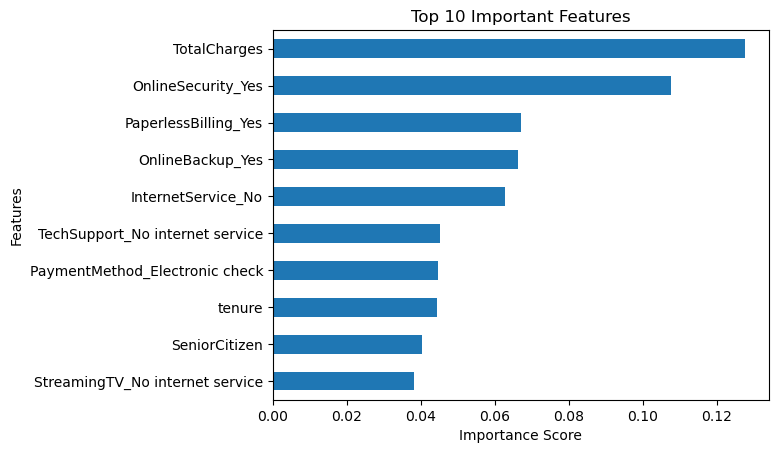

In [97]:
# Feature Importace: which feature has the mst impact on the models performance: 
importance = pd.Series(rf_model.feature_importances_, index=X.columns)

importance.sort_values().tail(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()